# Post mofa-flex analysis

### Contents:

1. [Load models (Normal, SnS, and GP).](#load-models)

2. [MOFA-Flex model result overview.](#mofa-flex-results-overview)
<br>
2.1 [Factor correlation and variance explained.](#1-variance-explained)
<br>
2.2 [Average R2.](#2-average-r2)
<br>
2.3 [Weights distribution.](#3weights-dist)
<br>
2.4 [Heatmap (view x LR).](#4-heatmap-view-x-lr)

3. [DR and clustering.](#dr-using-factors-values)

4. [Regression Model.](#regression-model)
<br>
4.1 [Evaluate model.](#evaluate-the-model)
<br>
4.2 [AUC.](#auc)

5. [Map clusters to spatial.](#map-clusters-to-spatial)

In [ ]:
import os.path
import anndata as ad
import mudata as md
import numpy as np
import pandas as pd
import mofaflex as mfl
from plotnine import *
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from umap import UMAP
from sklearn.manifold import TSNE

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



# Load models

### Normal

In [2]:
models_path = Path("/g/stegle/aalsayah/repos/data/models_obj")

In [3]:
model= mfl.MOFAFLEX.load(models_path / 'crc_120.hdf5')

WARNING	The stored model was created with a different version of MOFA-FLEX. Some features may not work.


### SnS

In [ ]:
#model = mfl.MOFAFLEX.load(models_path / "sns_models/crc_110/Normal.SnS/crc_110.Normal.SnS.hdf5")

WARNING	The stored model was created with a different version of MOFA-FLEX. Some features may not work.


### GP

In [ ]:
#model = mfl.MOFAFLEX.load(models_path / "GP_models/crc_232_no_mye_IgM/GP.Normal/crc_232_no_mye_IgM.GP.Normal.hdf5")

# MOFA-Flex results overview

## 1. Variance Explained

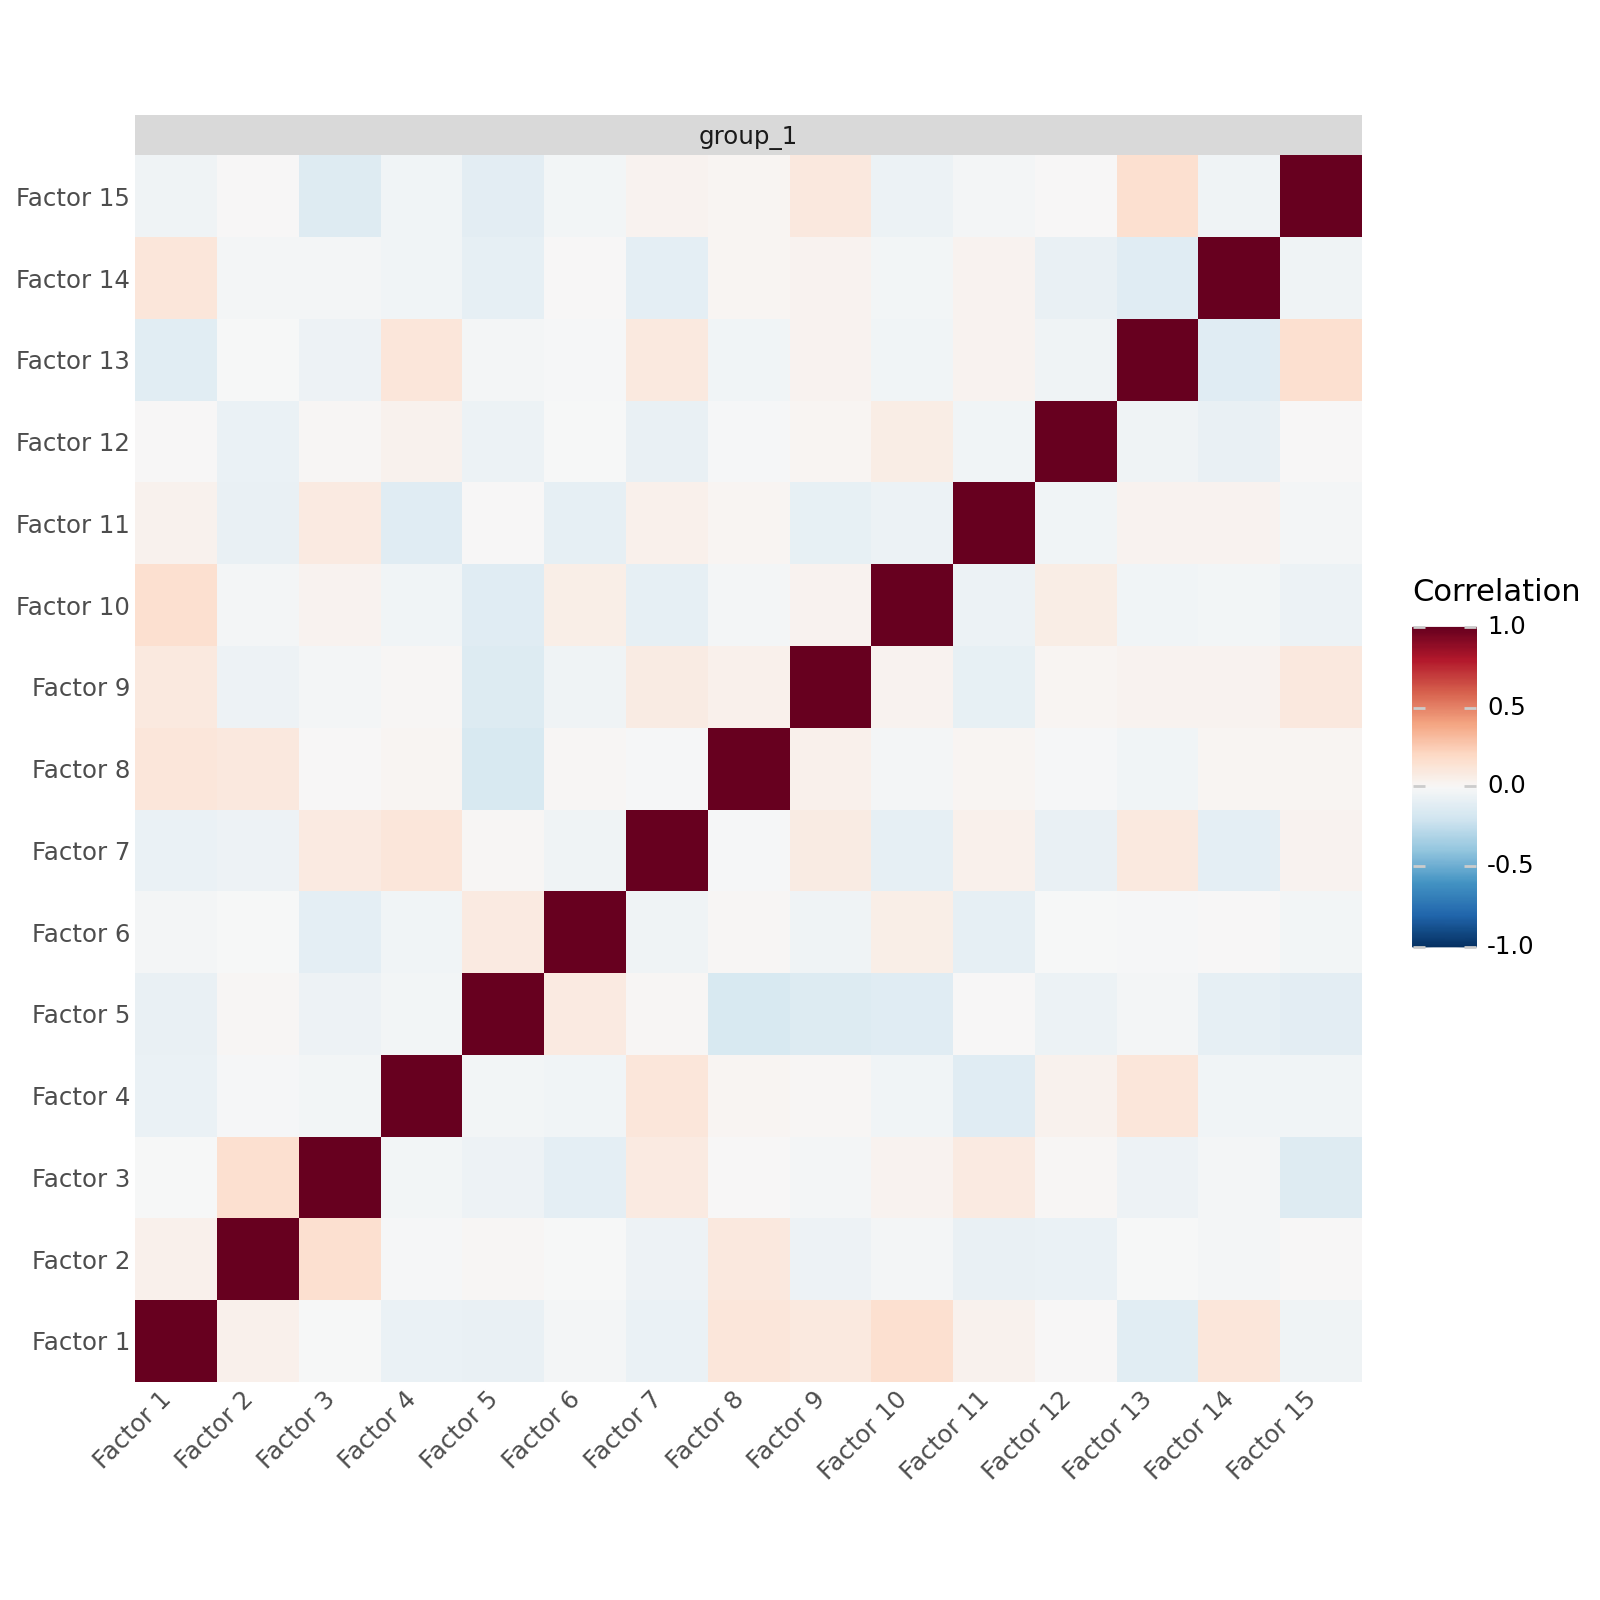

In [4]:
mfl.pl.factor_correlation(model)

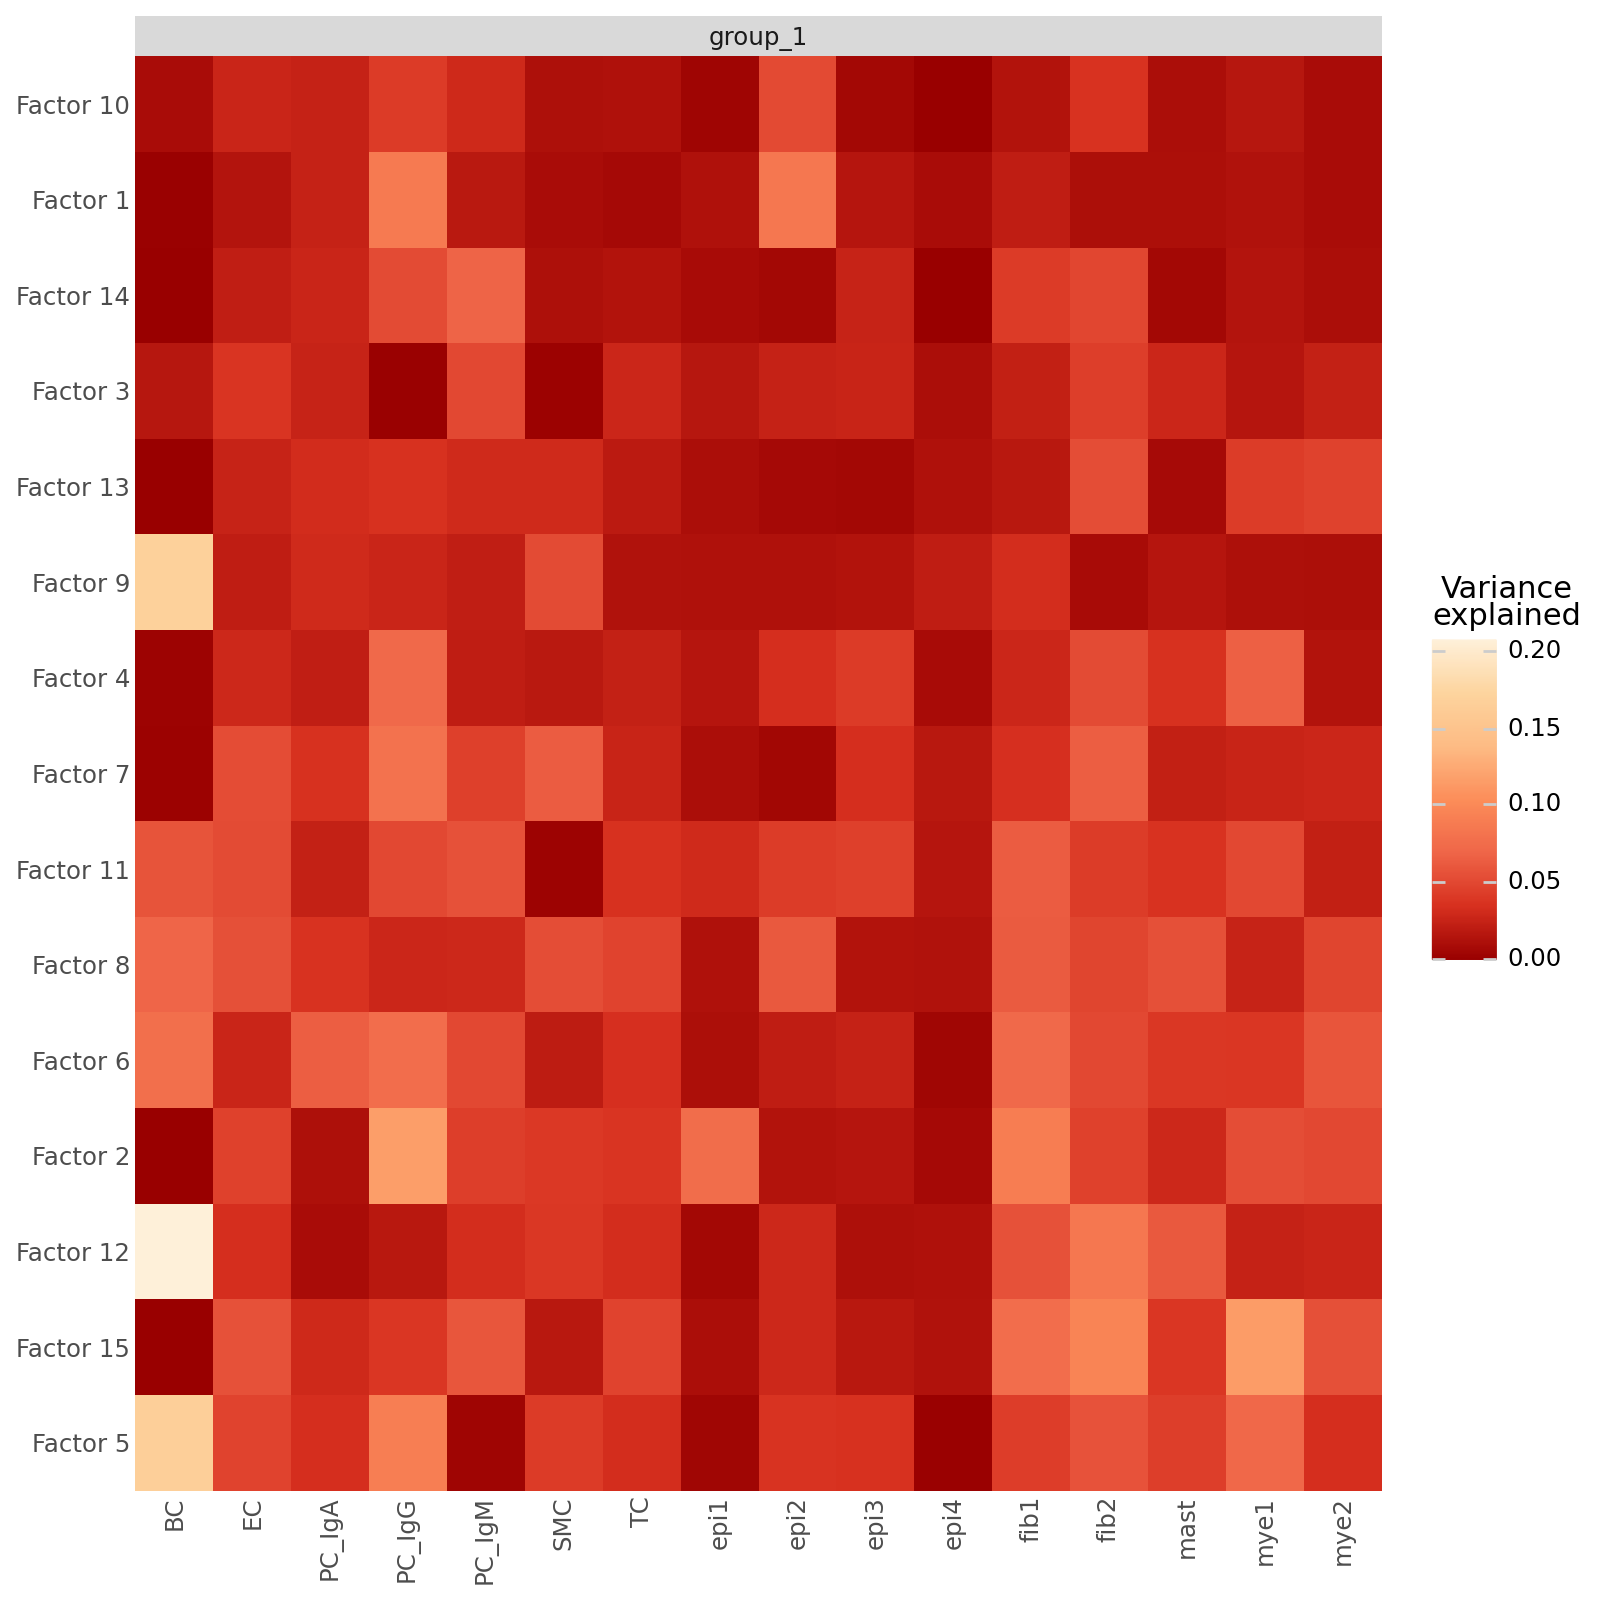

In [5]:
mfl.pl.variance_explained(model, figsize= (8,8))

## 2. Average R2

In [6]:
print(model.get_r2(total=True))

         group_1
epi2    0.415089
epi3    0.400566
epi1    0.307643
epi4    0.274606
BC      0.734008
mye1    0.527353
EC      0.507686
fib2    0.710413
TC      0.385763
mye2    0.368643
PC_IgA  0.473887
mast    0.495085
PC_IgM  0.604148
fib1    0.566617
PC_IgG  0.795614
SMC     0.479074


In [7]:
r2 = model.get_r2(total=True)
r2["group_1"].mean()

0.5028870961875211

## 3.Weights dist

In [8]:
weights_dict= model.get_weights()

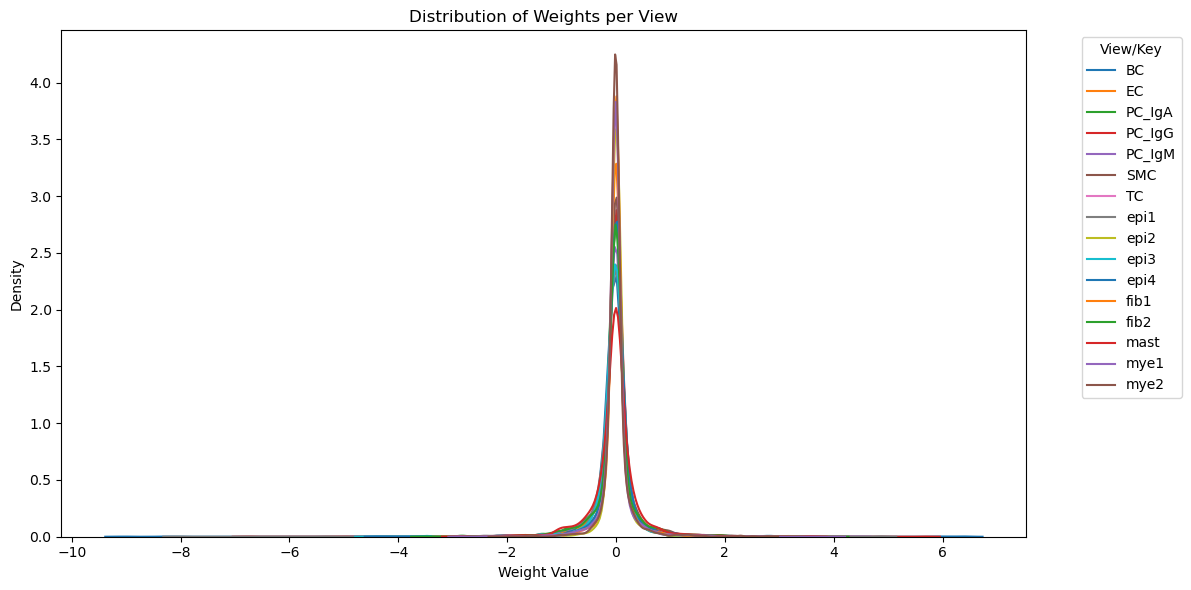

In [9]:
plt.figure(figsize=(12, 6))

# Loop through each view/key
for key, df in weights_dict.items():
    # Flatten all weights from that DataFrame into 1D array
    values = df.values.flatten()
    sns.kdeplot(values, label=key, fill=False)  # distribution curve

plt.title("Distribution of Weights per View")
plt.xlabel("Weight Value")
plt.ylabel("Density")
plt.legend(title="View/Key", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [10]:
#mfl.pl.all_weights(model_gp, views=['fib2'], figsize=(8,8), show_featurenames=True)
#mfl.pl.weights(model, n_features=10, views=["fib2"], factors=1, pointsize=2, figsize=(8,8))
#mfl.pl.top_weights(model, n_features=15, views="fib2", factors=1)

## 4. Heatmap (view x LR)

In [10]:
from string import ascii_uppercase
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

In [11]:
weights = model.get_weights()

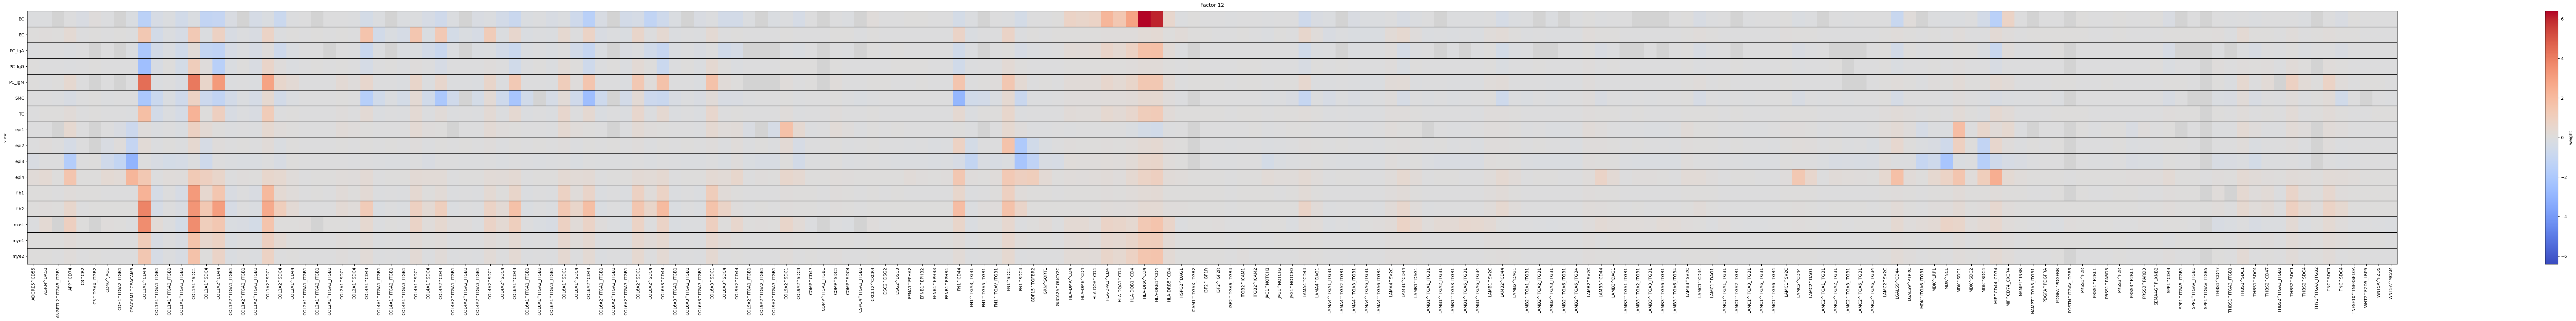

In [12]:
import re
from matplotlib.colors import TwoSlopeNorm

# choose the factor you want:
factor = 12

def resolve_factor_label(df, factor):
    """
    Return the exact row label in df.index for a given factor selector.
    Accepts: 3, "3", "Factor 3", "factor 03", etc.
    """
    idx_map = {str(idx).strip().lower(): idx for idx in df.index}
    key = str(factor).strip().lower()
    # exact match first
    if key in idx_map:
        return idx_map[key]
    # otherwise pull the first integer and try "Factor {n}"
    m = re.search(r'\d+', key)
    if m:
        candidate = f"factor {int(m.group())}"
        if candidate in idx_map:
            return idx_map[candidate]
    raise KeyError(f"Couldn't find factor '{factor}'. Available: {list(df.index)}")

rows, labels = [], []
for view, df in weights.items():
    row_label = resolve_factor_label(df, factor)
    s = df.loc[row_label].copy()
    s.index = ['^'.join(c.split('^')[1:]) for c in s.index]  # drop prefix before first ^
    rows.append(s)
    labels.append(view)

# assemble matrix (align columns across views)
all_cols = sorted({c for s in rows for c in s.index})
X = pd.DataFrame([s.reindex(all_cols) for s in rows], index=labels)

plt.figure(figsize=(0.5*X.shape[1] + 2, 0.6*X.shape[0] + 1))

# zero-centered diverging colormap
v = np.nanmax(np.abs(X.values))
norm = TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v)
cmap = plt.get_cmap('coolwarm').copy()
cmap.set_bad('lightgray')  # NaNs

im = plt.imshow(np.ma.masked_invalid(X.values),
                aspect='auto', interpolation='nearest',
                cmap=cmap, norm=norm)

plt.yticks(range(X.shape[0]), X.index)
plt.xticks(range(X.shape[1]), X.columns, rotation=90)
plt.ylabel("view")
plt.colorbar(im, label="weight")
for r in range(1, X.shape[0]):
    plt.axhline(r - 0.5, color='black', lw=1)
plt.title(f"Factor {factor}", pad=10)  # shows "Factor 3" if you passed 3
plt.tight_layout()
plt.show()


# DR using factors values

In [13]:
factors = model.get_factors()
factors = factors["group_1"]

In [14]:
factors

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15
c_2_9_12,0.266703,0.101879,-0.307371,-0.961243,0.419664,0.232172,0.120603,0.759599,0.122820,-0.463962,0.267210,0.865022,-0.808947,-0.581125,0.750308
c_2_9_13,-0.248551,0.190406,0.005828,0.111807,0.186468,0.190942,0.175634,-0.225077,-0.177048,-0.225578,-0.059039,-0.087594,0.444590,0.009703,0.237288
c_2_9_15,1.344536,-1.474728,-1.120180,-1.281171,1.079411,-0.894599,1.077793,-2.055596,-1.834425,-1.051323,-0.440384,1.678088,-2.600793,2.353148,-0.287090
c_2_9_25,-0.468833,0.066577,0.015106,0.108513,0.177625,0.167640,0.069448,-0.220191,-0.171962,0.040498,-0.221443,-0.093578,0.196256,-0.270144,-0.155233
c_2_9_27,-0.117144,0.053550,-1.200663,0.078396,-0.136437,0.471604,-1.014584,0.415955,-0.343487,0.060674,-1.081503,1.204992,-0.049561,0.256148,0.516749
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c_2_395_52,2.239117,1.735877,2.015965,3.569386,0.735638,-1.713651,2.050417,1.702954,1.167088,1.241395,-1.342945,-0.957139,0.875439,-2.474366,-1.298997
c_2_395_104,-0.229889,-0.145711,0.224447,1.530296,-0.447665,0.388308,1.280265,0.322807,0.572076,0.690690,-0.448851,-0.983339,1.083381,-1.023797,-0.260758
c_2_396_1131,-0.443437,-0.529108,-0.605472,2.656840,-0.168354,0.730945,1.405898,0.822216,-0.276469,1.650978,0.153645,-0.613820,1.216175,-1.710069,0.144849
c_2_396_1197,1.707199,-2.024439,-1.359452,-0.939228,0.051765,-1.755911,-0.534248,-1.733663,1.477176,1.975968,0.985277,0.375482,2.234905,-1.407363,-0.038259


### Load lrdata

In [15]:
data_path = Path("/g/stegle/aalsayah/repos/data/lrdata_processed")
lrdata = sc.read_h5ad(data_path/ "crc_120_lrdata.h5ad")

In [16]:
lv1 = lrdata.obs["lv1"]
lv2 = lrdata.obs["lv2"]
ist = lrdata.obs["ist"]
typ = lrdata.obs["typ"]

In [17]:
lv1 = lv1.loc[lv1.index.intersection(factors.index)]
lv1 = lv1.reindex(factors.index)
lv1.shape

(454731,)

## UMAP

In [20]:
import umap.umap_ as umap
from sklearn.preprocessing import StandardScaler
import hdbscan

In [21]:
# --- Standardize ---
scaler = StandardScaler()
X = scaler.fit_transform(factors)

### higher-D

In [22]:
# --- UMAP for clustering (higher-D) ---
umap_clusters = umap.UMAP(
    n_components=10,
    n_neighbors=50,         
    min_dist=0.2,           
    metric="euclidean",      
    random_state=42
).fit_transform(X)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


In [23]:
# --- HDBSCAN: start conservative ---
n = X.shape[0]
mcs = max(30, int(np.sqrt(n)))  
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=mcs,
    min_samples=None,               
    cluster_selection_method="eom",  
    cluster_selection_epsilon=0.05  
).fit(umap_clusters)

labels = clusterer.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise_rate = (labels == -1).mean()
print(f"clusters={n_clusters}, noise={noise_rate:.2%}")

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.


clusters=30, noise=10.96%


#### 2D UMAP

In [24]:
# --- 2D UMAP for visualization only ---
umap2 = umap.UMAP(
    n_components=2,
    n_neighbors=50,
    min_dist=0.2,
    metric="euclidean",
    random_state=42
).fit_transform(X)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


In [26]:
df_umap = pd.DataFrame(umap2, columns=['UMAP1','UMAP2'], index=factors.index)
df_umap['Cluster'] = labels
df_umap['Conf'] = clusterer.probabilities_  # how confident each assignment is

#### Plot UMAP

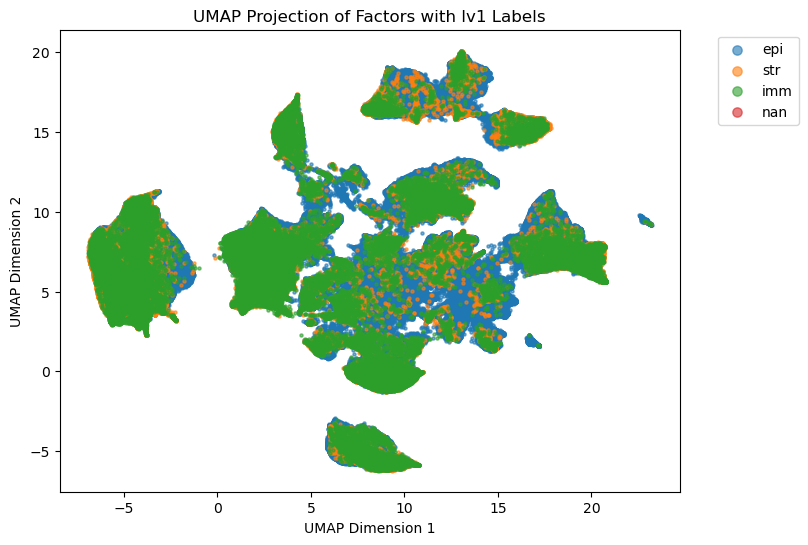

In [27]:
df_umap['Label'] = lv1.loc[factors.index].values

# Step 4: Plot UMAP with labels
plt.figure(figsize=(8,6))
for label in df_umap['Label'].unique():
    subset = df_umap[df_umap['Label'] == label]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=label)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Projection of Factors with lv1 Labels")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

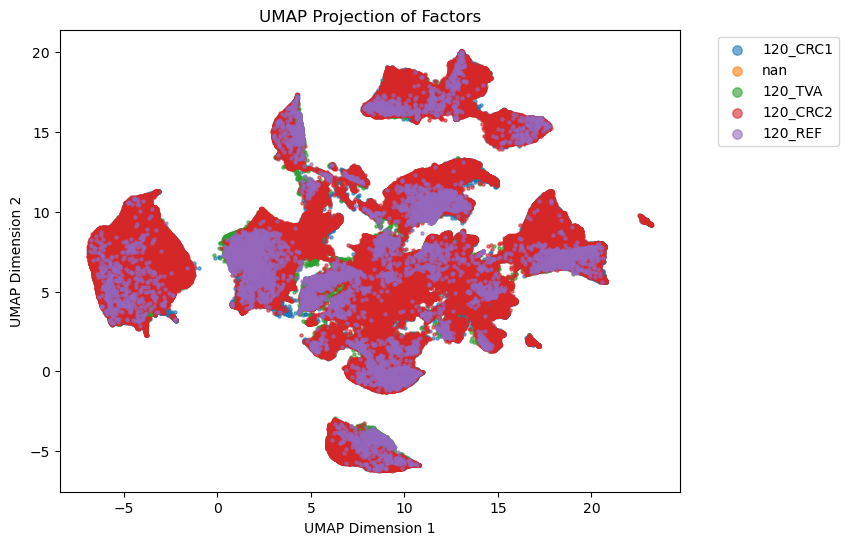

In [28]:
df_umap['Label'] = typ.loc[factors.index].values

# Step 4: Plot UMAP with labels
plt.figure(figsize=(8,6))
for label in df_umap['Label'].unique():
    subset = df_umap[df_umap['Label'] == label]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=label)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Projection of Factors")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

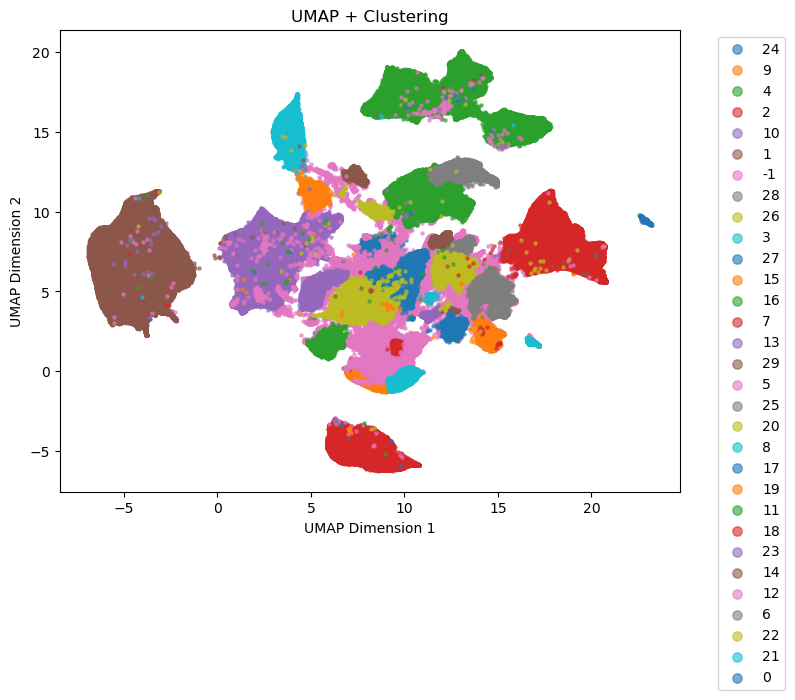

In [29]:
#Plot clusters

plt.figure(figsize=(8,6))
for label in df_umap['Cluster'].unique():
    subset = df_umap[df_umap['Cluster'] == label]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=label)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP + Clustering")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Regression Model

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [31]:
#get variables 
factors = model.get_factors() 
F = factors["group_1"]

#Get dependent var, change typ to any metadata column you wish to predict if factor values can predict
cell_names = F.index
cell_types = lrdata.obs["typ"]

#Sort both
cell_types = cell_types.sort_index()
F=  F.sort_index()

#Filter out any datapoint in response var that is not in features
filtered_cell_types = cell_types.loc[cell_types.index.isin(cell_names)]

### Create X and Y objects

In [32]:
F

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15
c_2_100_10,0.121523,-0.478061,-0.438057,-0.413230,0.062945,-0.616784,0.037283,-0.656531,0.507323,0.210382,0.121613,0.028016,0.902993,-0.741013,0.338754
c_2_100_100,-0.704160,-0.338387,0.718933,-0.073914,-0.572679,-0.733047,0.064630,-0.272150,0.204885,-0.663015,0.329042,0.758867,0.044881,0.893698,-0.504626
c_2_100_1002,0.200522,0.241730,0.117778,-0.084662,-0.034373,0.003153,0.115575,0.237550,0.316385,-0.003821,-0.084869,-0.277304,0.055134,-0.082428,-0.095144
c_2_100_1006,0.566499,0.065879,-1.135329,-0.002505,-0.035250,0.172480,0.576018,-0.363149,-0.898285,-0.624966,0.292827,-0.390405,-0.299129,-0.064983,-0.626090
c_2_100_1007,0.056914,0.129756,0.021644,0.082386,-0.211516,-0.043131,0.115686,0.127606,0.270710,0.022138,-0.343967,-0.193785,0.121553,-0.093178,-0.030447
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c_2_9_987,-0.650716,0.274422,-0.788827,1.331022,1.296027,0.119962,0.456847,-0.743359,1.046990,-1.063554,-2.670510,1.276927,-0.468454,-0.208310,-0.127478
c_2_9_99,-0.459601,0.002243,0.014083,0.131613,0.169438,0.159306,0.058346,-0.252628,-0.197365,0.078752,-0.168904,-0.114555,0.179229,-0.356715,-0.277758
c_2_9_993,0.292377,-0.748634,-0.409439,-0.447498,1.055497,0.862940,1.417726,0.827123,0.603491,-0.273214,0.685377,0.943938,-1.138825,-0.836403,0.045547
c_2_9_995,0.875856,0.913435,0.764115,-0.049995,0.255100,0.888682,0.405867,-0.471647,-0.188214,0.471818,0.775988,0.053625,0.970778,0.718054,0.406925


In [33]:
filtered_cell_types

c_2_100_10      120_CRC1
c_2_100_100     120_CRC1
c_2_100_1002    120_CRC1
c_2_100_1006    120_CRC1
c_2_100_1007    120_CRC1
                  ...   
c_2_9_987       120_CRC1
c_2_9_99        120_CRC1
c_2_9_993       120_CRC1
c_2_9_995       120_CRC1
c_2_9_999       120_CRC1
Name: typ, Length: 454731, dtype: category
Categories (4, object): ['120_CRC1', '120_CRC2', '120_REF', '120_TVA']

In [34]:
X = F.values
y = filtered_cell_types.values  # labels

In [35]:
#Drop NaN labels
mask = ~pd.isna(y)
X = X[mask]
y = y[mask]

In [36]:
print(X.shape, y.shape)

(445567, 15) (445567,)


In [37]:
print("Min:", np.min(X))
print("Max:", np.max(X))
print("Mean:", np.mean(X))
print("Median:", np.median(X))
print("Std dev:", np.std(X))

Min: -4.5896373
Max: 4.551555
Mean: 0.00025850305
Median: 0.0024694933
Std dev: 0.5179435


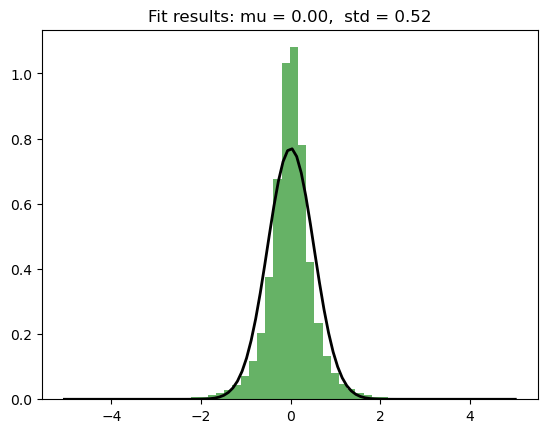

In [38]:
from scipy.stats import norm

data = X.flatten()

# histogram
plt.hist(data, bins=50, density=True, alpha=0.6, color='g')

# fit a normal
mu, std = norm.fit(data)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2)

plt.title(f"Fit results: mu = {mu:.2f},  std = {std:.2f}")
plt.show()


### Train multinomial logistic regression

In [39]:
# Split data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [40]:
clf = LogisticRegression(
    solver="lbfgs",
    max_iter=200,
    class_weight="balanced"
)

In [41]:
clf.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=200)

### Evaluate the model

In [42]:
# Evaluate
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.27365696373933013

Classification Report:
               precision    recall  f1-score   support

    120_CRC1       0.43      0.29      0.35     47961
    120_CRC2       0.53      0.22      0.31     66863
     120_REF       0.04      0.44      0.08      3003
     120_TVA       0.16      0.43      0.23     15844

    accuracy                           0.27    133671
   macro avg       0.29      0.34      0.24    133671
weighted avg       0.44      0.27      0.31    133671



### AUC

In [43]:
from sklearn.metrics import roc_auc_score, roc_curve

#### 1. If threr are 2 classes only (REF vs. CRC)

AUC: 0.6078538535729829


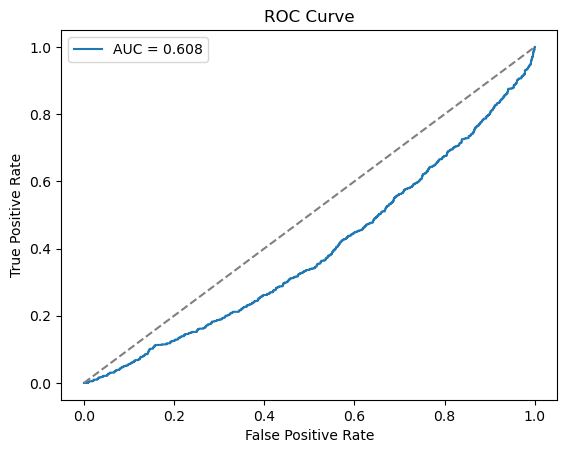

In [87]:
# Get predicted probabilities for the positive class (assume label "232_REF" is positive)
y_pred_proba = clf.predict_proba(X_test)[:, 1]

# Calculate AUC
auc = roc_auc_score(y_test, y_pred_proba)
print("AUC:", auc)


fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba, pos_label="222_REF")
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

#### 2. If classes are more than 2:

In [44]:
# Get class probabilities 
y_proba = clf.predict_proba(X_test)   # shape = (n_samples, 3)

# Compute macro-average AUC (each class equally weighted, good default)
auc_macro = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
print(f"Multiclass ROC AUC (OvR, macro): {auc_macro:.4f}")

# You could also try weighted averaging (weights by class support):
auc_weighted = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
print(f"Multiclass ROC AUC (OvR, weighted): {auc_weighted:.4f}")


Multiclass ROC AUC (OvR, macro): 0.5867
Multiclass ROC AUC (OvR, weighted): 0.5501


# Map clusters to spatial 

In [45]:
df_umap

,UMAP1,UMAP2,Cluster,Conf,Label
c_2_9_12,9.268921,8.056169,24,1.000000,120_CRC1
c_2_9_13,6.934584,-0.079537,9,0.809590,120_CRC1
c_2_9_15,11.487412,17.493128,4,1.000000,120_CRC1
c_2_9_25,6.237801,-3.519409,2,0.908809,120_CRC1
c_2_9_27,3.557305,5.784838,10,1.000000,120_CRC1
...,...,...,...,...,...
c_2_395_52,-2.231474,3.211496,1,0.359816,120_CRC1
c_2_395_104,-3.049545,4.002290,1,0.702429,120_CRC1
c_2_396_1131,-3.009493,3.747631,1,0.630643,120_CRC1
c_2_396_1197,4.204860,16.731937,3,0.780356,120_CRC1


In [46]:
clusters = df_umap['Cluster'].reindex(lrdata.obs_names)
print(f"Missing cluster labels: {clusters.isna().sum()}")

Missing cluster labels: 285867


In [47]:
lrdata.obs['Cluster'] = clusters.astype('category')

/scratch/jobs/37429356/ipykernel_2919112/1180120996.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


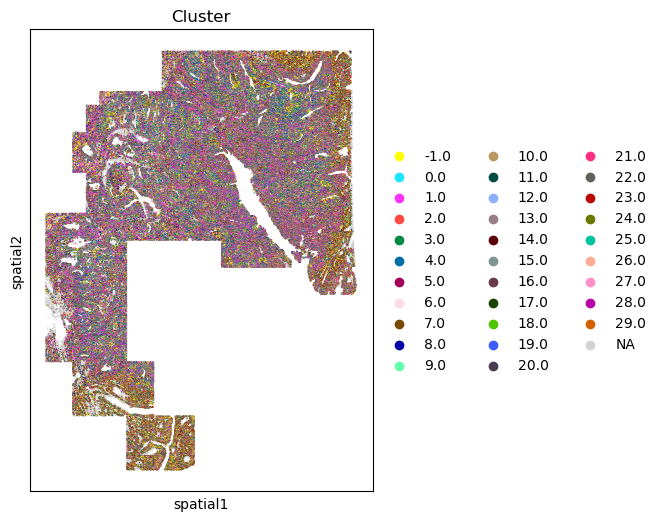

In [48]:
fig, axes = plt.subplots(1, 1, figsize=(6, 6))
sc.pl.spatial(
    lrdata,
    color='Cluster',
    spot_size=40,
    ax=axes
)
plt.tight_layout()